# Crop Recommendation System — ML Pipeline
### M32895 Big Data Applications Coursework

In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("Crop_recommendation.csv")

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Column names: {list(df.columns)}")
df.head(10)

Dataset shape: 2200 rows x 8 columns
Column names: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


## 2. Data Validation

In [5]:
print("=== Data Types ===")
print(df.dtypes)
print(f"\nAll feature columns are numeric: {all(df.drop('label', axis=1).dtypes.apply(lambda x: np.issubdtype(x, np.number)))}")

=== Data Types ===
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

All feature columns are numeric: True


In [6]:
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

=== Missing Values ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total missing values: 0


In [7]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("Removing duplicates...")
    df = df.drop_duplicates()
    print(f"Shape after removing duplicates: {df.shape}")
else:
    print("No duplicates found — dataset is clean.")

Number of duplicate rows: 0
No duplicates found — dataset is clean.


In [8]:
print("=== Statistical Summary ===")
df.describe().round(2)

=== Statistical Summary ===


,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


In [9]:
print("=== Value Range Validation ===")
for col in df.select_dtypes(include=[np.number]).columns:
    print(f"{col:>12s}: min = {df[col].min():.2f}, max = {df[col].max():.2f}")

ph_valid = df['ph'].between(0, 14).all()
print(f"\npH values within valid range (0-14): {ph_valid}")

nutrients_valid = (df[['N', 'P', 'K']] >= 0).all().all()
print(f"All nutrient values non-negative: {nutrients_valid}")

=== Value Range Validation ===
           N: min = 0.00, max = 140.00
           P: min = 5.00, max = 145.00
           K: min = 5.00, max = 205.00
 temperature: min = 8.83, max = 43.68
    humidity: min = 14.26, max = 99.98
          ph: min = 3.50, max = 9.94
    rainfall: min = 20.21, max = 298.56

pH values within valid range (0-14): True
All nutrient values non-negative: True


## 3. Data Preparation

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

print("=== Label Mapping ===")
for crop, code in sorted(zip(le.classes_, le.transform(le.classes_)), key=lambda x: x[1]):
    print(f"  {code:2d} -> {crop}")

X = df.drop(['label', 'label_encoded'], axis=1)
y = df['label_encoded']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"Number of classes: {len(le.classes_)}")

=== Label Mapping ===
   0 -> apple
   1 -> banana
   2 -> blackgram
   3 -> chickpea
   4 -> coconut
   5 -> coffee
   6 -> cotton
   7 -> grapes
   8 -> jute
   9 -> kidneybeans
  10 -> lentil
  11 -> maize
  12 -> mango
  13 -> mothbeans
  14 -> mungbean
  15 -> muskmelon
  16 -> orange
  17 -> papaya
  18 -> pigeonpeas
  19 -> pomegranate
  20 -> rice
  21 -> watermelon

Features shape: (2200, 7)
Target shape:   (2200,)
Number of classes: 22


In [11]:
from sklearn.model_selection import train_test_split

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Second split: 75% of temp = 60% total train, 25% of temp = 20% total validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

Training set:   1320 samples (60%)
Validation set: 440 samples (20%)
Test set:       440 samples (20%)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Feature scaling applied (StandardScaler).")
print(f"\nScaled training set — mean per feature:\n{X_train_scaled.mean().round(4).to_string()}")
print(f"\nScaled training set — std per feature:\n{X_train_scaled.std().round(4).to_string()}")

Feature scaling applied (StandardScaler).

Scaled training set — mean per feature:
N             -0.0
P              0.0
K              0.0
temperature    0.0
humidity      -0.0
ph             0.0
rainfall      -0.0

Scaled training set — std per feature:
N              1.0004
P              1.0004
K              1.0004
temperature    1.0004
humidity       1.0004
ph             1.0004
rainfall       1.0004


## 4. Exploratory Data Analysis (EDA)

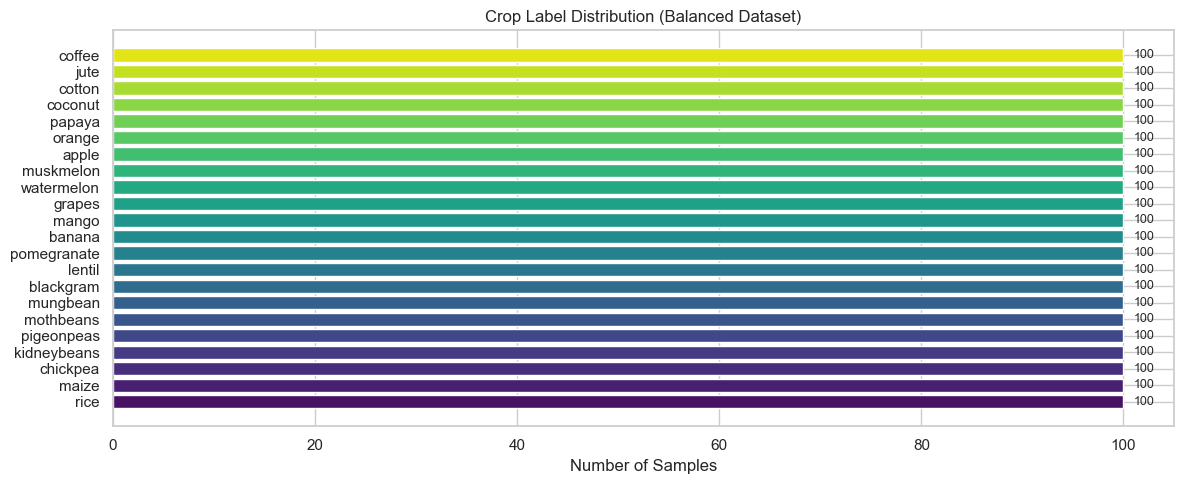

Each crop has exactly 100 samples — the dataset is perfectly balanced.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

fig, ax = plt.subplots(figsize=(12, 5))
crop_counts = df['label'].value_counts().sort_values(ascending=True)
bars = ax.barh(crop_counts.index, crop_counts.values, color=sns.color_palette("viridis", len(crop_counts)))
ax.set_xlabel("Number of Samples")
ax.set_title("Crop Label Distribution (Balanced Dataset)")
for bar, val in zip(bars, crop_counts.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(val),
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Each crop has exactly {crop_counts.values[0]} samples — the dataset is perfectly balanced.")

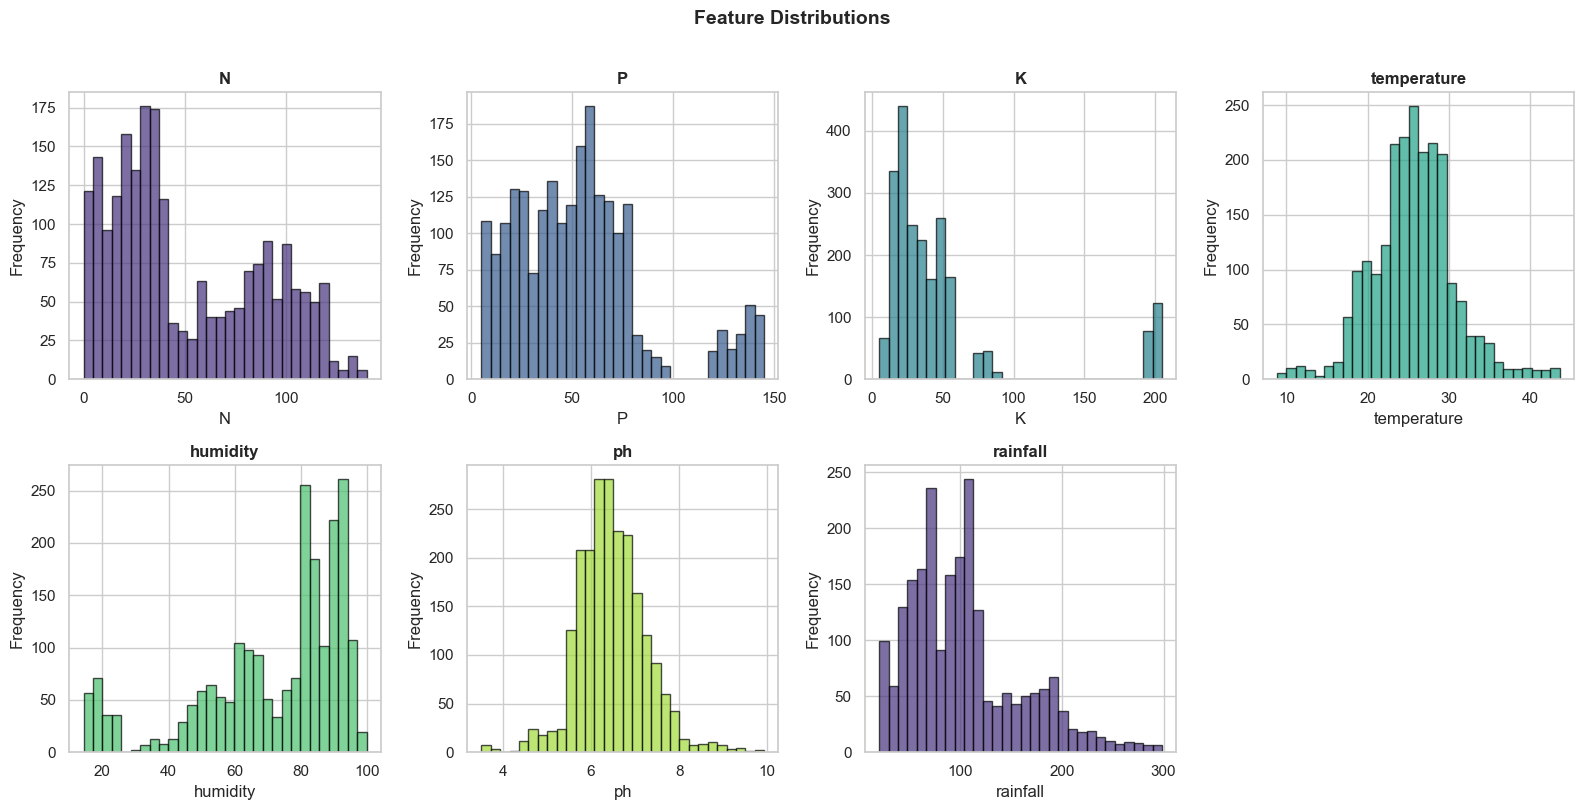

In [15]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color=sns.color_palette("viridis")[i % 6], edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[-1].set_visible(False)
fig.suptitle("Feature Distributions", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

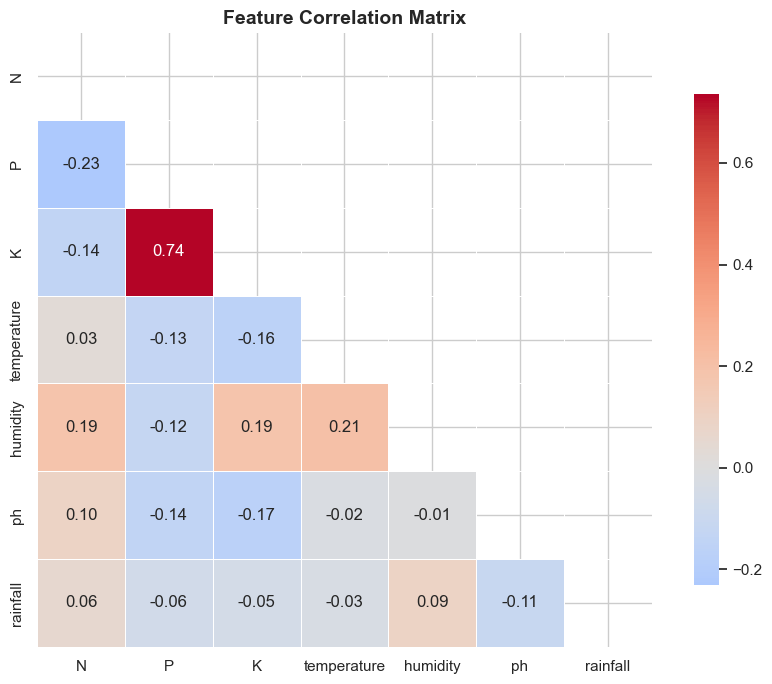

Low correlation between features means each one provides independent information.


In [16]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Low correlation between features means each one provides independent information.")

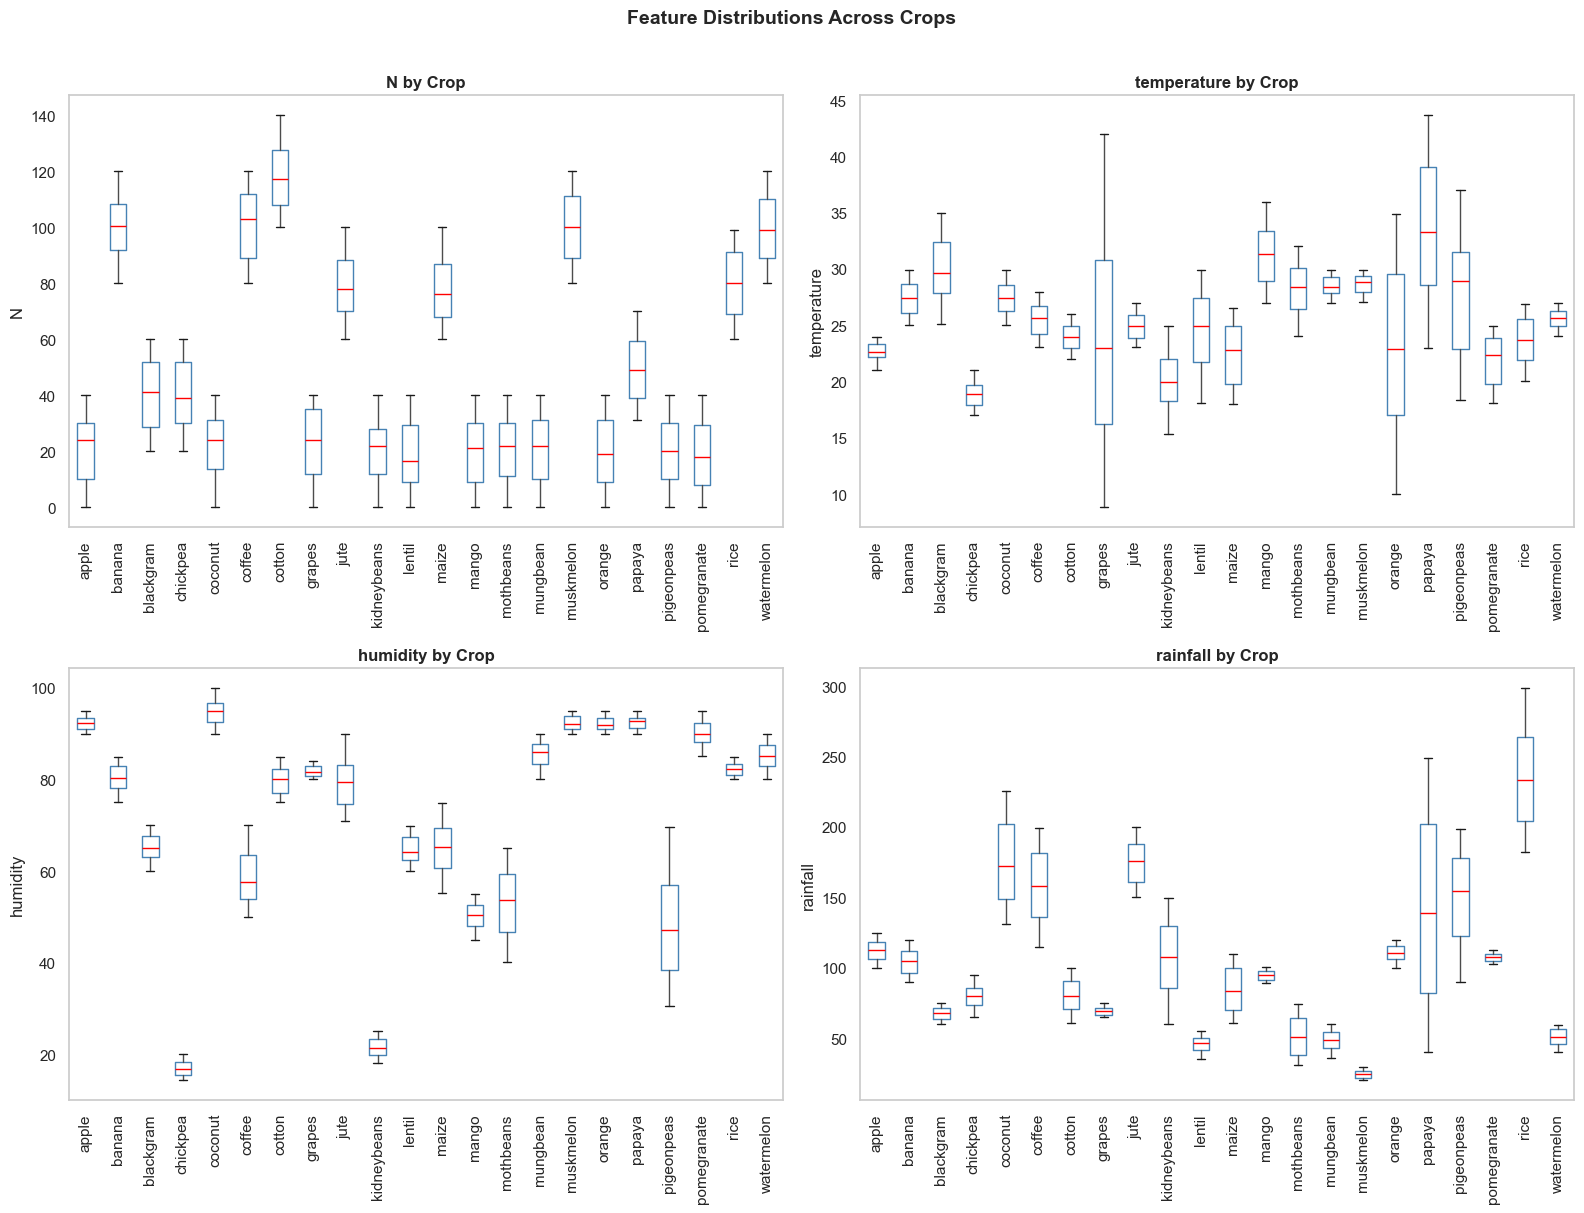

Different crops clearly prefer different environmental conditions.


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, feature in zip(axes.flatten(), ['N', 'temperature', 'humidity', 'rainfall']):
    df.boxplot(column=feature, by='label', ax=ax, rot=90, grid=False,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red'))
    ax.set_title(f'{feature} by Crop', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(feature)

plt.suptitle("Feature Distributions Across Crops", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Different crops clearly prefer different environmental conditions.")

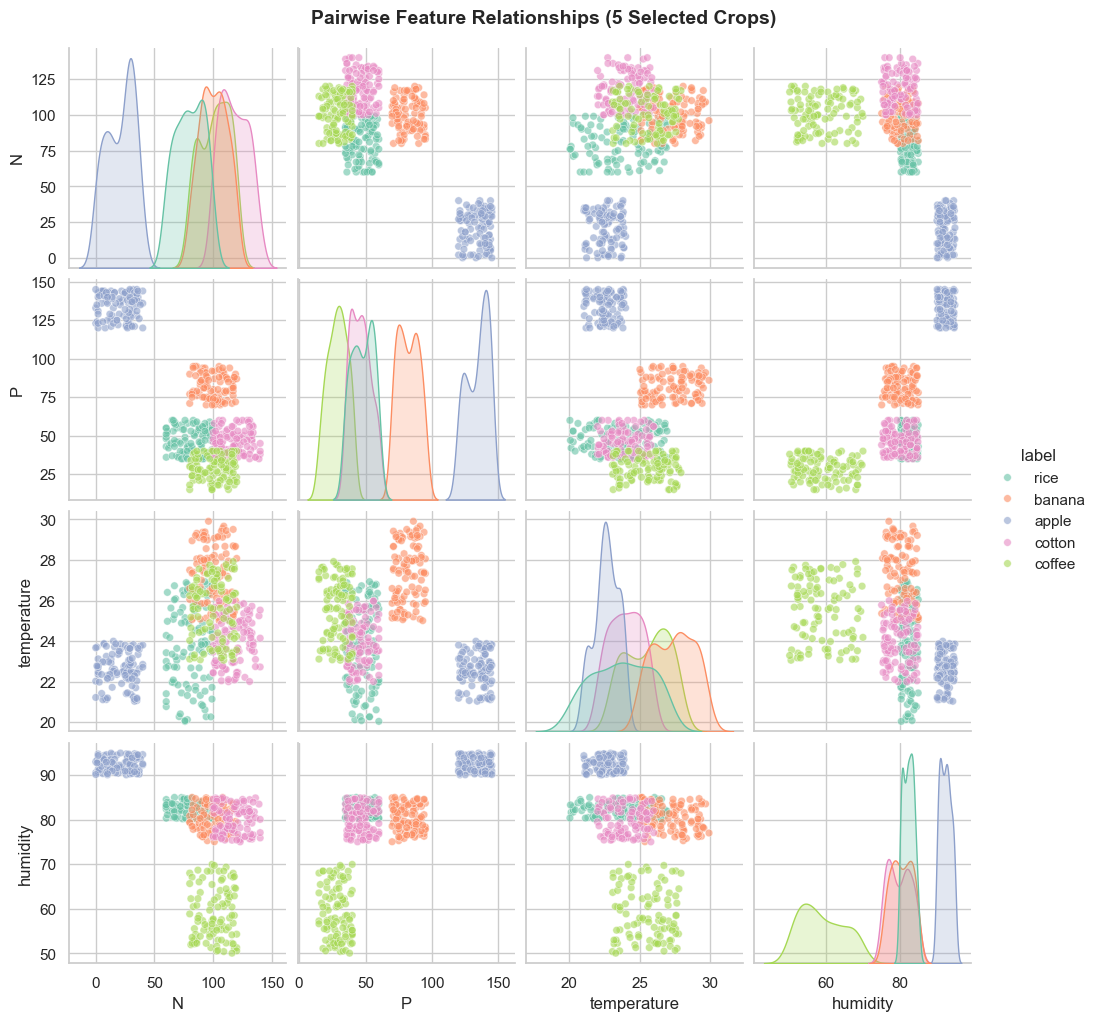

Clear clustering shows these features can separate crops effectively.


In [18]:
sample_crops = ['rice', 'coffee', 'apple', 'cotton', 'banana']
df_sample = df[df['label'].isin(sample_crops)]

g = sns.pairplot(df_sample, hue='label', vars=['N', 'P', 'temperature', 'humidity'],
                 palette='Set2', diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30})
g.figure.suptitle("Pairwise Feature Relationships (5 Selected Crops)", y=1.02, fontsize=14, fontweight='bold')
plt.show()

print("Clear clustering shows these features can separate crops effectively.")

## 5. Model Building

Three classification models are trained and compared:
1. **Decision Tree** — A single tree that splits data based on feature thresholds
2. **Random Forest** — An ensemble of many Decision Trees for better accuracy
3. **Logistic Regression** — A statistical approach that learns decision boundaries

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train_scaled, y_train)

y_val_pred_dt = dt_baseline.predict(X_val_scaled)
dt_val_acc = accuracy_score(y_val, y_val_pred_dt)

print("=== Decision Tree — Baseline ===")
print(f"Validation Accuracy: {dt_val_acc:.4f} ({dt_val_acc*100:.2f}%)")
print(f"\nClassification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_dt, target_names=le.classes_))

=== Decision Tree — Baseline ===
Validation Accuracy: 0.9818 (98.18%)

Classification Report (Validation Set):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       0.95      1.00      0.98        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.90      0.90      0.90        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      0.95      0.95        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      0.95      0.95        20
    mungbean       1.00      0.95      0.97        20
   muskmelon       1.00 

In [20]:
cv_scores_dt = cross_val_score(dt_baseline, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"5-Fold Cross-Validation Accuracy: {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std():.4f})")
print(f"Individual fold scores: {[f'{s:.4f}' for s in cv_scores_dt]}")

5-Fold Cross-Validation Accuracy: 0.9841 (+/- 0.0081)
Individual fold scores: ['0.9697', '0.9886', '0.9886', '0.9811', '0.9924']


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train_scaled, y_train)

y_val_pred_rf = rf_baseline.predict(X_val_scaled)
rf_val_acc = accuracy_score(y_val, y_val_pred_rf)

print("=== Random Forest — Baseline ===")
print(f"Validation Accuracy: {rf_val_acc:.4f} ({rf_val_acc*100:.2f}%)")
print(f"\nClassification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_rf, target_names=le.classes_))

=== Random Forest — Baseline ===
Validation Accuracy: 0.9909 (99.09%)

Classification Report (Validation Set):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.90      0.95      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00 

In [22]:
cv_scores_rf = cross_val_score(rf_baseline, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"5-Fold Cross-Validation Accuracy: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")
print(f"Individual fold scores: {[f'{s:.4f}' for s in cv_scores_rf]}")

5-Fold Cross-Validation Accuracy: 0.9977 (+/- 0.0030)
Individual fold scores: ['0.9924', '1.0000', '1.0000', '1.0000', '0.9962']


In [23]:
from sklearn.linear_model import LogisticRegression

lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)

y_val_pred_lr = lr_baseline.predict(X_val_scaled)
lr_val_acc = accuracy_score(y_val, y_val_pred_lr)

print("=== Logistic Regression — Baseline ===")
print(f"Validation Accuracy: {lr_val_acc:.4f} ({lr_val_acc*100:.2f}%)")
print(f"\nClassification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_lr, target_names=le.classes_))

=== Logistic Regression — Baseline ===
Validation Accuracy: 0.9727 (97.27%)

Classification Report (Validation Set):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      0.90      0.92        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       0.95      1.00      0.98        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.89      0.85      0.87        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.90      0.95      0.93        20
       maize       1.00      1.00      1.00        20
       mango       0.95      1.00      0.98        20
   mothbeans       1.00      0.95      0.97        20
    mungbean       1.00      1.00      1.00        20
   muskmelon      

In [24]:
cv_scores_lr = cross_val_score(lr_baseline, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"5-Fold Cross-Validation Accuracy: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")
print(f"Individual fold scores: {[f'{s:.4f}' for s in cv_scores_lr]}")

5-Fold Cross-Validation Accuracy: 0.9644 (+/- 0.0082)
Individual fold scores: ['0.9773', '0.9545', '0.9697', '0.9583', '0.9621']


=== Baseline Model Comparison ===
              Model  Validation Accuracy  CV Mean Accuracy  CV Std
      Decision Tree               0.9818            0.9841  0.0081
      Random Forest               0.9909            0.9977  0.0030
Logistic Regression               0.9727            0.9644  0.0082


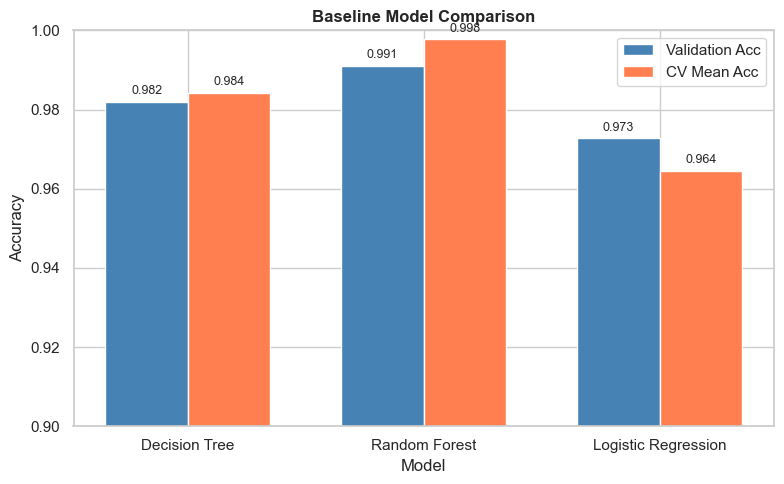

In [26]:
import pandas as pd

baseline_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Validation Accuracy': [dt_val_acc, rf_val_acc, lr_val_acc],
    'CV Mean Accuracy': [cv_scores_dt.mean(), cv_scores_rf.mean(), cv_scores_lr.mean()],
    'CV Std': [cv_scores_dt.std(), cv_scores_rf.std(), cv_scores_lr.std()]
}).round(4)

print("=== Baseline Model Comparison ===")
print(baseline_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(baseline_results))
width = 0.35
bars1 = ax.bar(x - width/2, baseline_results['Validation Accuracy'], width, label='Validation Acc', color='steelblue')
bars2 = ax.bar(x + width/2, baseline_results['CV Mean Accuracy'], width, label='CV Mean Acc', color='coral')
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Baseline Model Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(baseline_results['Model'])
ax.legend()
ax.set_ylim(0.9, 1.0)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Model Evaluation & Hyperparameter Optimisation

Using GridSearchCV to find the best hyperparameters for each model.

In [27]:
from sklearn.model_selection import GridSearchCV

dt_param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

print("Running GridSearchCV for Decision Tree...")
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
dt_grid.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {dt_grid.best_params_}")
print(f"Best CV accuracy: {dt_grid.best_score_:.4f}")

dt_tuned = dt_grid.best_estimator_
y_val_pred_dt_tuned = dt_tuned.predict(X_val_scaled)
dt_tuned_acc = accuracy_score(y_val, y_val_pred_dt_tuned)
print(f"Tuned validation accuracy: {dt_tuned_acc:.4f} (was {dt_val_acc:.4f})")

Running GridSearchCV for Decision Tree...

Best parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV accuracy: 0.9750
Tuned validation accuracy: 0.9750 (was 0.9818)


In [28]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15, 25],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print("Running GridSearchCV for Random Forest...")
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best CV accuracy: {rf_grid.best_score_:.4f}")

rf_tuned = rf_grid.best_estimator_
y_val_pred_rf_tuned = rf_tuned.predict(X_val_scaled)
rf_tuned_acc = accuracy_score(y_val, y_val_pred_rf_tuned)
print(f"Tuned validation accuracy: {rf_tuned_acc:.4f} (was {rf_val_acc:.4f})")

Running GridSearchCV for Random Forest...

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV accuracy: 0.9970
Tuned validation accuracy: 0.9932 (was 0.9909)


In [29]:
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'newton-cg'],
    'penalty': ['l2']
}

print("Running GridSearchCV for Logistic Regression...")
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
lr_grid.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {lr_grid.best_params_}")
print(f"Best CV accuracy: {lr_grid.best_score_:.4f}")

lr_tuned = lr_grid.best_estimator_
y_val_pred_lr_tuned = lr_tuned.predict(X_val_scaled)
lr_tuned_acc = accuracy_score(y_val, y_val_pred_lr_tuned)
print(f"Tuned validation accuracy: {lr_tuned_acc:.4f} (was {lr_val_acc:.4f})")

Running GridSearchCV for Logistic Regression...

Best parameters: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 0.9773
Tuned validation accuracy: 0.9773 (was 0.9727)


c:\Users\rosha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


=== Tuned Model Comparison ===
              Model  Baseline Val Acc  Tuned Val Acc  Improvement  Best CV Score
      Decision Tree            0.9818         0.9750      -0.0068         0.9750
      Random Forest            0.9909         0.9932       0.0023         0.9970
Logistic Regression            0.9727         0.9773       0.0045         0.9773

*** Best performing model: Random Forest ***
*** Validation accuracy: 0.9932 ***


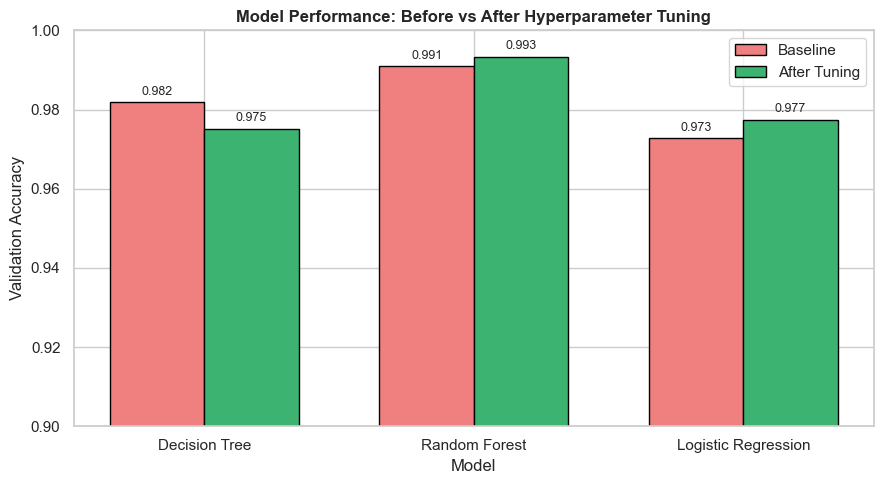

In [30]:
tuned_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Baseline Val Acc': [dt_val_acc, rf_val_acc, lr_val_acc],
    'Tuned Val Acc': [dt_tuned_acc, rf_tuned_acc, lr_tuned_acc],
    'Improvement': [dt_tuned_acc - dt_val_acc, rf_tuned_acc - rf_val_acc, lr_tuned_acc - lr_val_acc],
    'Best CV Score': [dt_grid.best_score_, rf_grid.best_score_, lr_grid.best_score_]
}).round(4)

print("=== Tuned Model Comparison ===")
print(tuned_results.to_string(index=False))

best_idx = tuned_results['Tuned Val Acc'].idxmax()
best_model_name = tuned_results.loc[best_idx, 'Model']
best_models = {'Decision Tree': dt_tuned, 'Random Forest': rf_tuned, 'Logistic Regression': lr_tuned}
best_model = best_models[best_model_name]
print(f"\n*** Best performing model: {best_model_name} ***")
print(f"*** Validation accuracy: {tuned_results.loc[best_idx, 'Tuned Val Acc']:.4f} ***")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(tuned_results))
width = 0.35
bars1 = ax.bar(x - width/2, tuned_results['Baseline Val Acc'], width, label='Baseline', color='lightcoral', edgecolor='black')
bars2 = ax.bar(x + width/2, tuned_results['Tuned Val Acc'], width, label='After Tuning', color='mediumseagreen', edgecolor='black')
ax.set_xlabel('Model')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Model Performance: Before vs After Hyperparameter Tuning', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(tuned_results['Model'])
ax.legend()
ax.set_ylim(0.9, 1.0)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

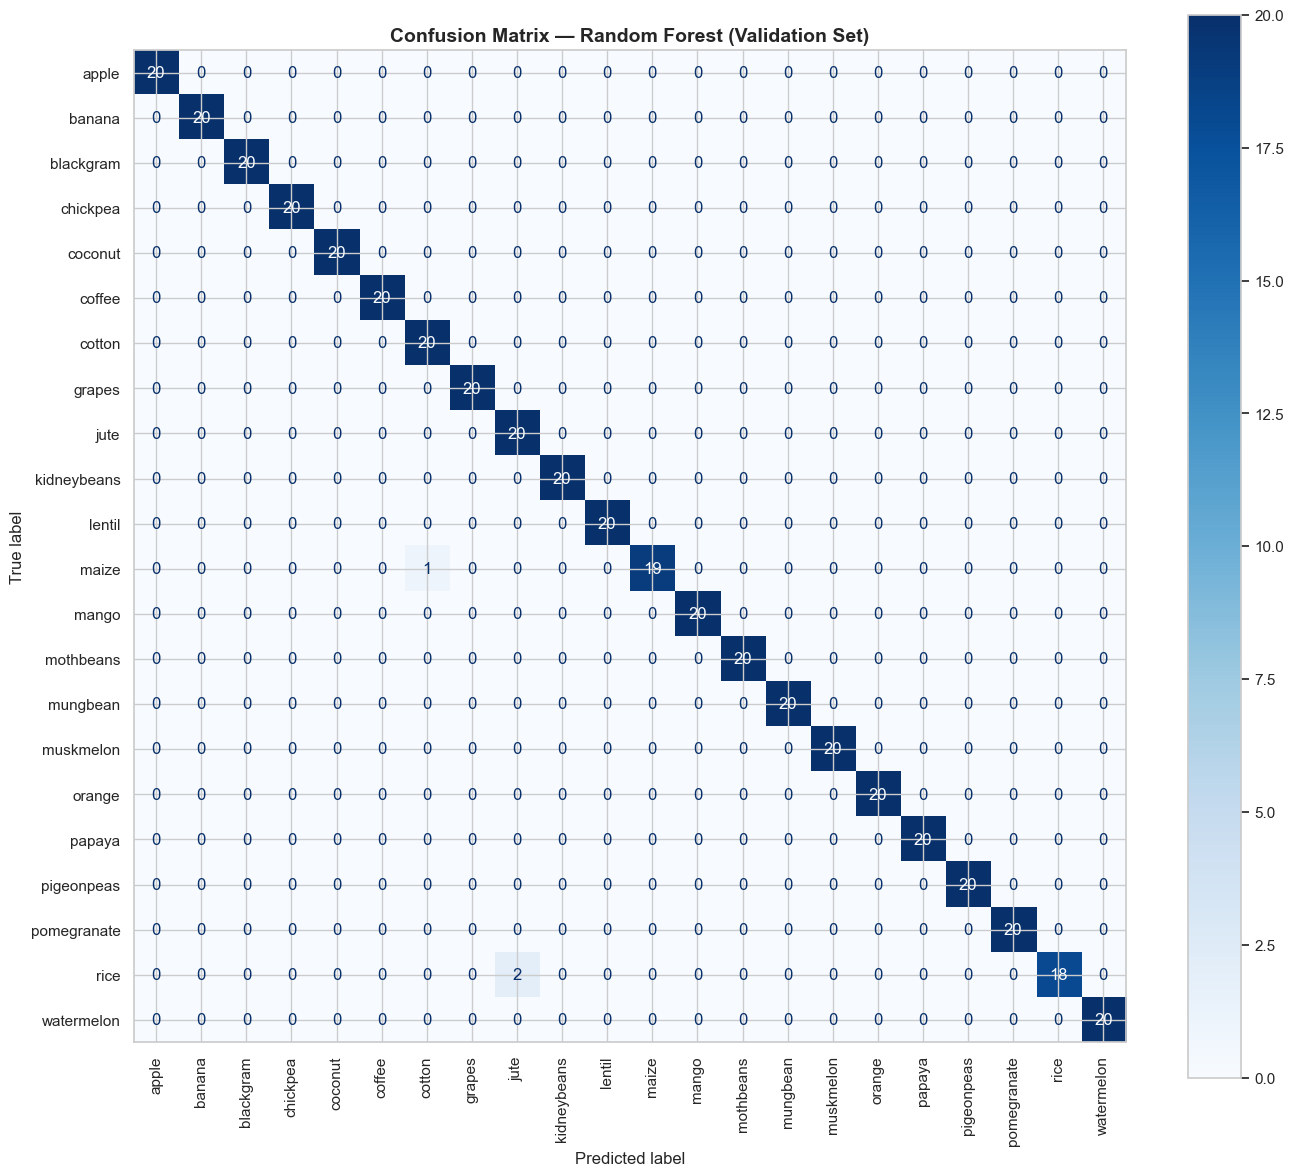

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_val_pred_best = best_model.predict(X_val_scaled)

fig, ax = plt.subplots(figsize=(14, 12))
cm = confusion_matrix(y_val, y_val_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=90)
ax.set_title(f'Confusion Matrix — {best_model_name} (Validation Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

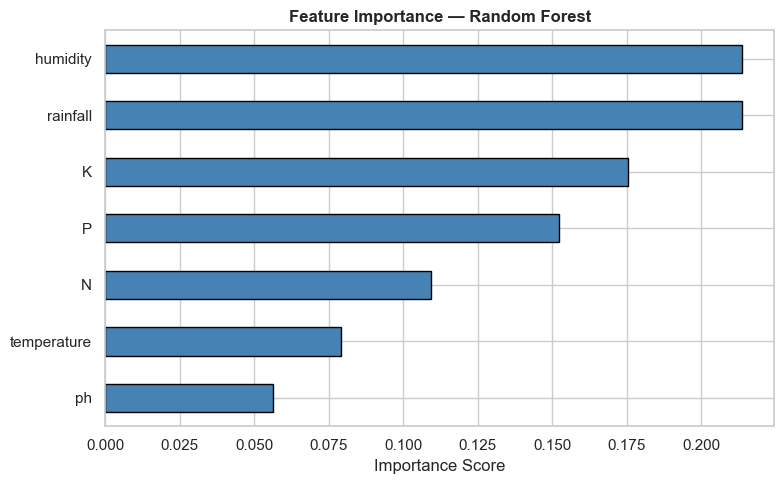

Feature importance ranking:
  1. humidity: 0.2137
  2. rainfall: 0.2136
  3. K: 0.1756
  4. P: 0.1523
  5. N: 0.1093
  6. temperature: 0.0791
  7. ph: 0.0564


In [32]:
importances = rf_tuned.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Feature Importance — Random Forest', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Feature importance ranking:")
for i, (feat, imp) in enumerate(feat_imp.sort_values(ascending=False).items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")

## 7. Prediction on Unseen Data

Evaluating the best model on the test set — data completely unseen during training and tuning.

hey how are you